<a href="https://colab.research.google.com/github/Ghalaahmed/MachineLearning/blob/main/lab4/%20lab4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Chocolate_Sales.csv")
df.head()

,Sales Person,Country,Product,Date,Amount,Boxes Shipped
0,Jehu Rudeforth,UK,Mint Chip Choco,04/01/2022,"$5,320.00",180
1,Van Tuxwell,India,85% Dark Bars,01/08/2022,"$7,896.00",94
2,Gigi Bohling,India,Peanut Butter Cubes,07/07/2022,"$4,501.00",91
3,Jan Morforth,Australia,Peanut Butter Cubes,27/04/2022,"$12,726.00",342
4,Jehu Rudeforth,UK,Peanut Butter Cubes,24/02/2022,"$13,685.00",184


##Task 1 : Identify data quality issues in the dataset

In [21]:
print("Raw data types:")
display(df.dtypes)

print("\nMissing values:")
display(df.isna().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Raw data types:


,0
Sales Person,object
Country,object
Product,object
Date,object
Amount,object
Boxes Shipped,int64



Missing values:


,0
Sales Person,0
Country,0
Product,0
Date,0
Amount,0
Boxes Shipped,0



Duplicate rows: 0


In [22]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')
df['Amount'] = df['Amount'].replace(r'[\$,]', '', regex=True)
df['Amount'] = pd.to_numeric(df['Amount'], errors='coerce')

print("Updated data types:")
display(df.dtypes)

print("\nMissing values after conversion:")
display(df.isna().sum())

Updated data types:


,0
Sales Person,object
Country,object
Product,object
Date,datetime64[ns]
Amount,float64
Boxes Shipped,int64



Missing values after conversion:


,0
Sales Person,0
Country,0
Product,0
Date,0
Amount,0
Boxes Shipped,0


## Data quality issues found:
### 1. Date was stored as object and needed conversion to datetime.
### 2. Amount was stored as object because it contained dollar signs/commas.
###3. After conversion, any invalid values become missing values (NaN).
### 4. Duplicate rows were checked.

#Task 2: Apply one missing value strategy and explain why

In [23]:
df_missing = df.copy()
df_missing.loc[0:5, 'Amount'] = np.nan

print("Missing values before handling:")
display(df_missing.isna().sum())

Missing values before handling:


,0
Sales Person,0
Country,0
Product,0
Date,0
Amount,6
Boxes Shipped,0


In [24]:
df_filled = df_missing.copy()
df_filled['Amount'] = df_filled['Amount'].fillna(df_filled['Amount'].median())

print("Missing values after handling:")
display(df_filled.isna().sum())

df_filled.head(10)

Missing values after handling:


,0
Sales Person,0
Country,0
Product,0
Date,0
Amount,0
Boxes Shipped,0


,Sales Person,Country,Product,Date,Amount,Boxes Shipped
0,Jehu Rudeforth,UK,Mint Chip Choco,2022-01-04,5220.745,180
1,Van Tuxwell,India,85% Dark Bars,2022-08-01,5220.745,94
2,Gigi Bohling,India,Peanut Butter Cubes,2022-07-07,5220.745,91
3,Jan Morforth,Australia,Peanut Butter Cubes,2022-04-27,5220.745,342
4,Jehu Rudeforth,UK,Peanut Butter Cubes,2022-02-24,5220.745,184
5,Van Tuxwell,India,Smooth Sliky Salty,2022-06-06,5220.745,38
6,Oby Sorrel,UK,99% Dark & Pure,2022-01-25,13685.000,176
7,Gunar Cockshoot,Australia,After Nines,2022-03-24,3080.000,73
8,Jehu Rudeforth,New Zealand,50% Dark Bites,2022-04-20,3990.000,59
9,Brien Boise,Australia,99% Dark & Pure,2022-07-04,2835.000,102


###The dataset originally had no missing values in the Amount column.
### To demonstrate a missing value handling strategy, some values were
###intentionally set to missing and then filled using the median.
### Median was chosen because it is less affected by outliers.

#Task 3: Detect and handle outliers using IQR

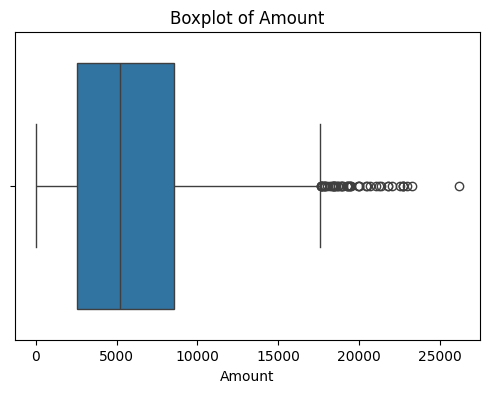

In [25]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df_filled['Amount'])
plt.title("Boxplot of Amount")
plt.show()

In [26]:
Q1 = df_filled['Amount'].quantile(0.25)
Q3 = df_filled['Amount'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df_filled[(df_filled['Amount'] < lower) | (df_filled['Amount'] > upper)]

print("Number of outliers:", outliers.shape[0])
display(outliers.head())

Number of outliers: 50


,Sales Person,Country,Product,Date,Amount,Boxes Shipped
66,Van Tuxwell,Australia,Organic Choco Syrup,2022-08-10,19453.0,14
135,Van Tuxwell,India,Organic Choco Syrup,2022-05-16,19929.0,174
212,Marney O'Breen,UK,Smooth Sliky Salty,2022-05-13,18991.0,88
434,Jan Morforth,New Zealand,Mint Chip Choco,2022-06-30,18340.0,285
543,Ches Bonnell,India,Peanut Butter Cubes,2022-01-27,22050.0,208


In [27]:
df_no_outliers = df_filled[(df_filled['Amount'] >= lower) & (df_filled['Amount'] <= upper)]

print("Original shape:", df_filled.shape)
print("Shape after removing outliers:", df_no_outliers.shape)

Original shape: (3282, 6)
Shape after removing outliers: (3232, 6)


###Outliers were detected using the IQR method.
### Values below the lower bound or above the upper bound were treated as outliers.
### I handled them by removing those rows.

#Task 4: Normalize numerical features using both Min-Max and Z-score

In [28]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

numerical_cols = ['Amount', 'Boxes Shipped']

In [29]:
minmax_scaler = MinMaxScaler()
df_minmax = df_no_outliers.copy()
df_minmax[numerical_cols] = minmax_scaler.fit_transform(df_minmax[numerical_cols])

print("Min-Max Normalization:")
display(df_minmax[numerical_cols].head())

Min-Max Normalization:


,Amount,Boxes Shipped
0,0.29662,0.230373
1,0.29662,0.119691
2,0.29662,0.115830
3,0.29662,0.438867
4,0.29662,0.235521


In [30]:
zscore_scaler = StandardScaler()
df_zscore = df_no_outliers.copy()
df_zscore[numerical_cols] = zscore_scaler.fit_transform(df_zscore[numerical_cols])

print("Z-Score Normalization:")
display(df_zscore[numerical_cols].head())

Z-Score Normalization:


,Amount,Boxes Shipped
0,-0.14543,0.121823
1,-0.14543,-0.569696
2,-0.14543,-0.593819
3,-0.14543,1.424452
4,-0.14543,0.153987


### Min-Max normalization scales values between 0 and 1.
### Z-score normalization transforms values so the mean becomes 0
### and the standard deviation becomes 1.

#Task 5: Apply PCA only if the numerical features show a correlation

In [31]:
corr_matrix = df_zscore[numerical_cols].corr()
print("Correlation matrix:")
display(corr_matrix)

Correlation matrix:


,Amount,Boxes Shipped
Amount,1.000000,-0.009908
Boxes Shipped,-0.009908,1.000000


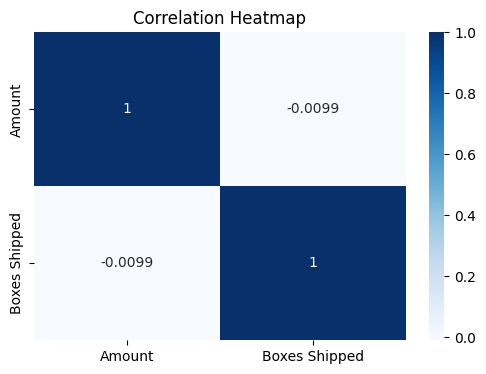

In [32]:
plt.figure(figsize=(6,4))
sns.heatmap(corr_matrix, annot=True, cmap='Blues')
plt.title("Correlation Heatmap")
plt.show()

In [33]:
correlation_value = corr_matrix.loc['Amount', 'Boxes Shipped']
print("Correlation between Amount and Boxes Shipped:", correlation_value)

Correlation between Amount and Boxes Shipped: -0.009907743573002432


In [34]:
from sklearn.decomposition import PCA

if abs(correlation_value) > 0.3:
    pca = PCA(n_components=2)
    principal_components = pca.fit_transform(df_zscore[numerical_cols])

    print("Explained Variance Ratio:", pca.explained_variance_ratio_)

    plt.figure(figsize=(6,4))
    plt.scatter(principal_components[:, 0], principal_components[:, 1])
    plt.title("PCA Projection")
    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")
    plt.show()
else:
    print("PCA was not applied because the numerical features are not sufficiently correlated.")

PCA was not applied because the numerical features are not sufficiently correlated.


### PCA should be applied only when features show correlation.
### Since PCA works best when variables are related, we first checked the correlation.
### If the correlation is strong enough, PCA is applied.